# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc236fa"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069]] [[0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066]] [[0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081]] ... [[0.245 0.245 0.245 ... 0.262 0.263 0.264] [0.245 0.245 0.245 ... 0.26199999999999996 0.263 0.264] [0.245 0.245 0.245 ... 0.267 0.26299999999999996 0.264] [0.245 0.245 0.245 ... 0.2676666666666666 0.2658333333333333 0.264] [0.245 0.245 0.245 ... 0.2648333333333333 0.263 0.264] [0.245 0.245 0.245 ... 0.262 0.263 0.264]] [[0.247 0.247 0.247 ... 0.264 0.265 0.266] [0.247 0.247 0.247 ... 0.264 0.265 0.266] [0.247 0.247 0.247 ... 0.267 0.265 0.266] [0.247 0.247 0.247 ... 0.271 0.2685 0.266] [0.247 0.247 0.247 ... 0.2675 0.265 0.266] [0.247 0.247 0.247 ... 0.264 0.265 0.266]] [[0.248 0.248 0.248 ... 0.264 0.265 0.266] [0.248 0.248 0.248 ... 0.264 0.265 0.266] [0.248 0.248 0.248 ... 0.26625 0.265 0.266] [0.248 0.248 0.248 ... 0.2723333333333333 0.26916666666666667 0.266] [0.248 0.248 0.248 ... 0.26816666666666666 0.265 0.266] [0.248 0.248 0.248 ... 0.264 0.265 0.266]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069] [0.058 0.058 0.058 ... 0.069 0.069 0.069]] [[0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066] [0.059 0.059 0.059 ... 0.066 0.066 0.066]] [[0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081] [0.059 0.059 0.059 ... 0.081 0.081 0.081]] ... [[0.245 0.245 0.245 ... 0.262 0.263 0.264] [0.245 0.245 0.245 ... 0.26199999999999996 0.263 0.264] [0.245 0.245 0.245 ... 0.267 0.26299999999999996 0.264] [0.245 0.245 0.245 ... 0.2676666666666666 0.2658333333333333 0.264] [0.245 0.245 0.245 ... 0.2648333333333333 0.263 0.264] [0.245 0.245 0.245 ... 0.262 0.263 0.264]] [[0.247 0.247 0.247 ... 0.264 0.265 0.266] [0.247 0.247 0.247 ... 0.264 0.265 0.266] [0.247 0.247 0.247 ... 0.267 0.265 0.266] [0.247 0.247 0.247 ... 0.271 0.2685 0.266] [0.247 0.247 0.247 ... 0.2675 0.265 0.266] [0.247 0.247 0.247 ... 0.264 0.265 0.266]] [[0.248 0.248 0.248 ... 0.264 0.265 0.266] [0.248 0.248 0.248 ... 0.264 0.265 0.266] [0.248 0.248 0.248 ... 0.26625 0.265 0.266] [0.248 0.248 0.248 ... 0.2723333333333333 0.26916666666666667 0.266] [0.248 0.248 0.248 ... 0.26816666666666666 0.265 0.266] [0.248 0.248 0.248 ... 0.264 0.265 0.266]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc236fa' (lon: 6, lat: 12, year: 16, month: 12)> Size: 111kB
<Quantity([[[[0.059      0.059      0.061      ... 0.071      0.071
    0.07      ]
   [0.07       0.072      0.074      ... 0.081      0.08
    0.078     ]
   [0.079      0.079      0.091      ... 0.083      0.083
    0.08      ]
   ...
   [0.217      0.194      0.244      ... 0.367      0.303
    0.215     ]
   [0.217      0.22       0.222      ... 0.226      0.228
    0.229     ]
   [0.231      0.232      0.234      ... 0.245      0.247
    0.248     ]]

  [[0.059      0.059      0.061      ... 0.071      0.071
    0.07      ]
   [0.07       0.072      0.074      ... 0.081      0.08
    0.078     ]
   [0.079      0.079      0.091      ... 0.083      0.083
    0.08      ]
...
   [0.22225    0.22308333 0.223      ... 0.22816667 0.2275
    0.22857143]
   [0.227      0.23533333 0.23866667 ... 0.24733333 0.25166667
    0.25033333]
   [0.25433333 0.25566667 0.257      ... 0.263      0.265
    0.265     ]]

  [[0.081      0.08       0.078      ... 0.081      0.081
    0.08      ]
   [0.082      0.084      0.086      ... 0.084      0.087
    0.086     ]
   [0.091      0.095      0.094      ... 0.093      0.095
    0.096     ]
   ...
   [0.223      0.2245     0.223      ... 0.231      0.226
    0.23225   ]
   [0.236      0.236      0.241      ... 0.246      0.253
    0.25      ]
   [0.255      0.255      0.257      ... 0.264      0.266
    0.266     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 128B 2008 2009 2010 2011 2012 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] ... [0.081 0.08 0.078 ... 0.262 0.264 0.264] [0.081 0.08 0.078 ... 0.263 0.265 0.265] [0.081 0.08 0.078 ... 0.264 0.266 0.266]] [[0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] ... [0.081 0.08 0.078 ... 0.26199999999999996 0.264 0.264] [0.081 0.08 0.078 ... 0.263 0.265 0.265] [0.081 0.08 0.078 ... 0.264 0.266 0.266]] [[0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] ... [0.081 0.08 0.078 ... 0.267 0.267 0.26625] [0.081 0.08 0.078 ... 0.26299999999999996 0.265 0.265] [0.081 0.08 0.078 ... 0.264 0.266 0.266]] [[0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] ... [0.081 0.08 0.078 ... 0.2676666666666666 0.271 0.2723333333333333] [0.081 0.08 0.078 ... 0.2658333333333333 0.2685 0.26916666666666667] [0.081 0.08 0.078 ... 0.264 0.266 0.266]] [[0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] ... [0.081 0.08 0.078 ... 0.2648333333333333 0.2675 0.26816666666666666] [0.081 0.08 0.078 ... 0.263 0.265 0.265] [0.081 0.08 0.078 ... 0.264 0.266 0.266]] [[0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] [0.059 0.059 0.061 ... 0.245 0.247 0.248] ... [0.081 0.08 0.078 ... 0.262 0.264 0.264] [0.081 0.08 0.078 ... 0.263 0.265 0.265] [0.081 0.08 0.078 ... 0.264 0.266 0.266]]]
Units,ppt


### Longitudinal-mean

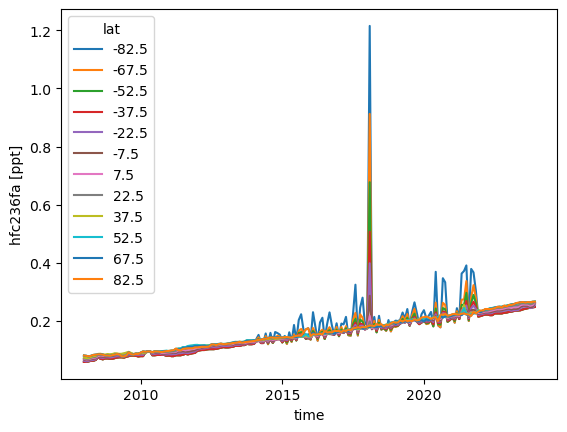

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

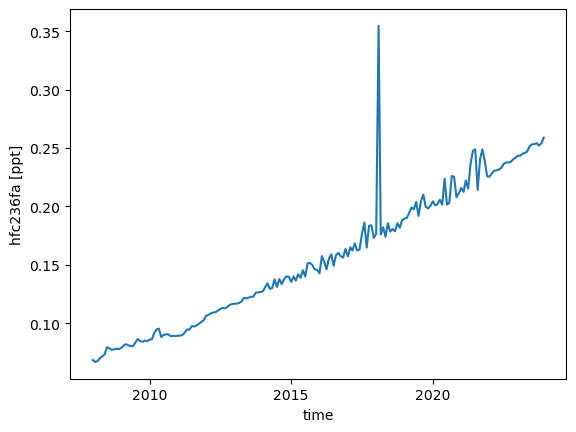

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

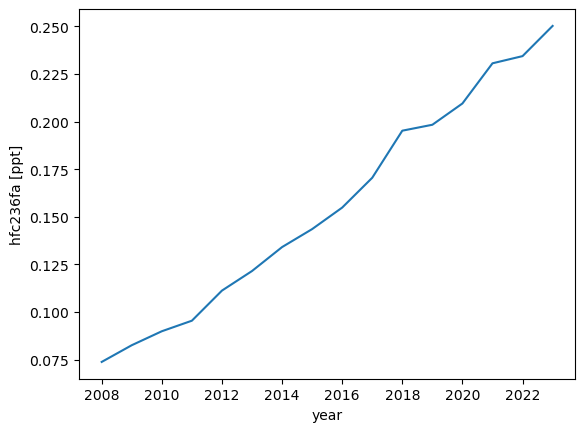

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 16)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 128B 2008 2009 2010 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.8274 ... -0.05329
    principal-components  (year, eof) float64 2kB [] -0.01616 ... 1.486e-17

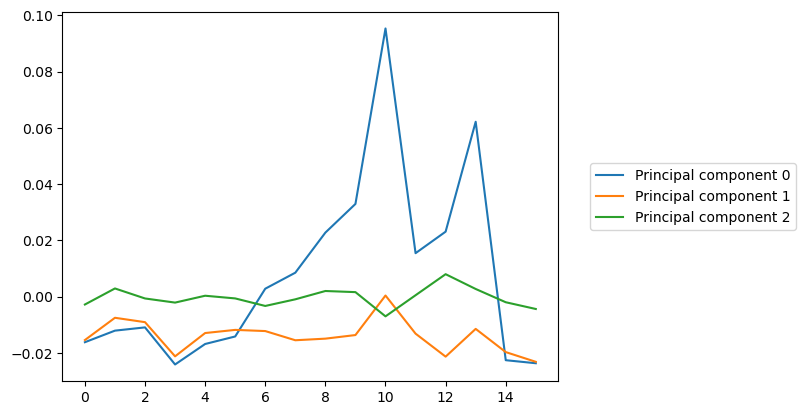

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

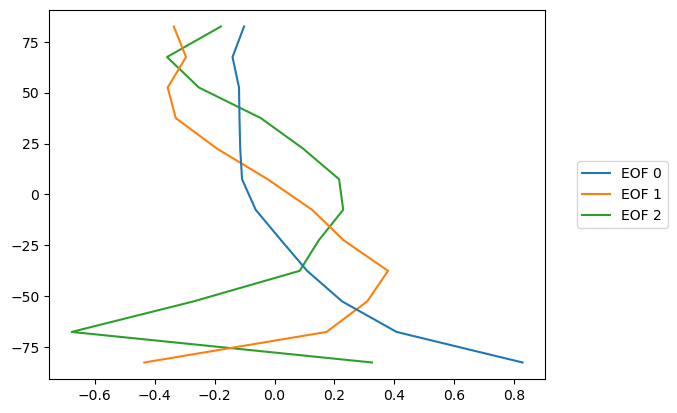

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

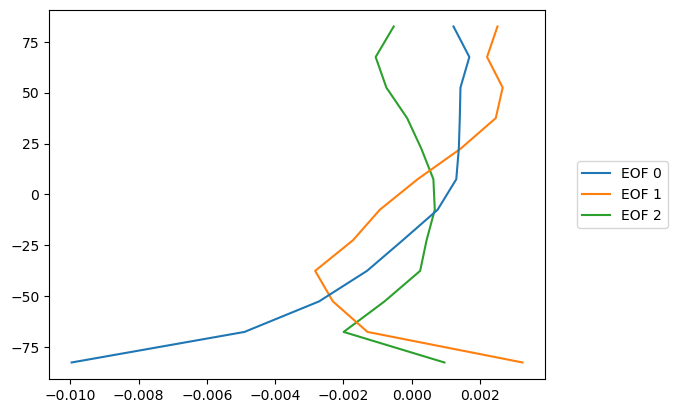

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.8274449536904627] [0.40700908004382014] [0.22540073312282696] [0.10873426558296952] [0.02205119281571207] [-0.06295359290214139] [-0.10841767639000502] [-0.11454925146292776] [-0.11694901604634908] [-0.11854639431059844] [-0.14022252884377528] [-0.10164553747160437]]
Units,ppt
Magnitude,[[-0.01615725955067327] [-0.012043579024329816] [-0.010887870815743472] [-0.024066517718501334] [-0.016786128223792933] [-0.014116216947449804] [0.0028587274984673877] [0.008551694609791147] [0.02279544497307505] [0.03298550961081367] [0.09533013891304147] [0.015483158342861422] [0.02312791847730986] [0.06218746547192733] [-0.022545974209711106] [-0.023624561386140296]]
Units,dimensionless


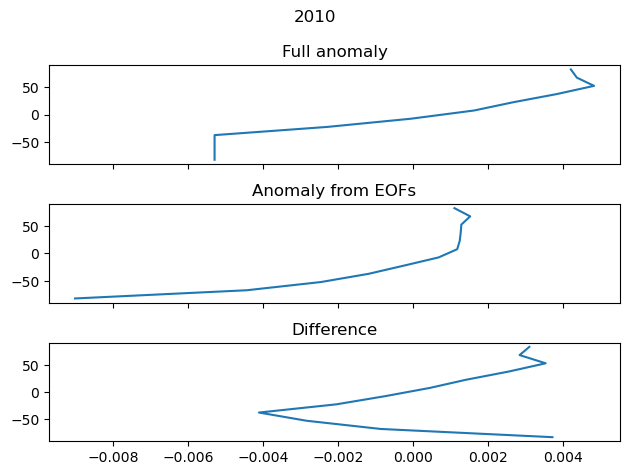

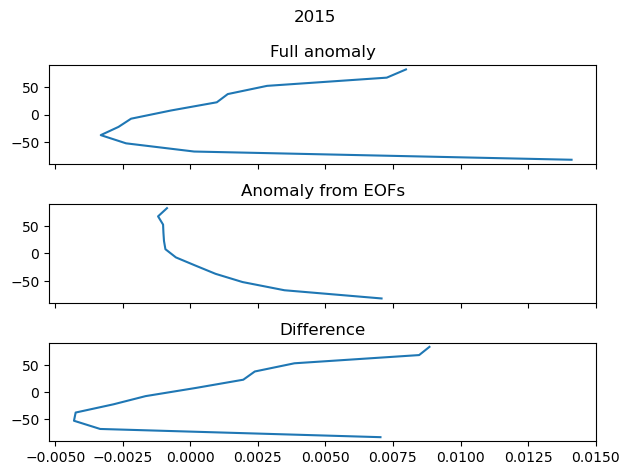

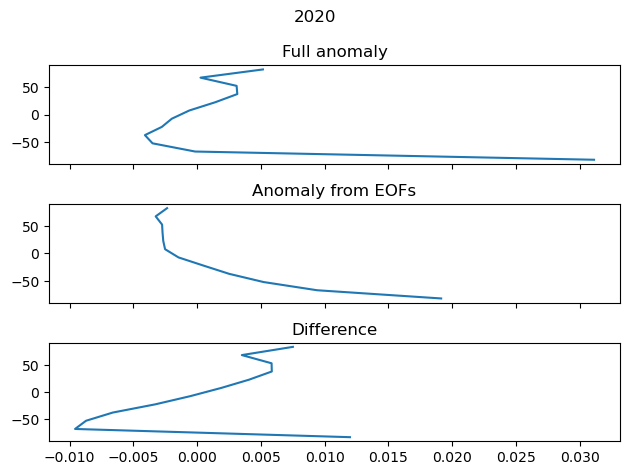

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 12565.44it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19230.74it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19813.66it/s]

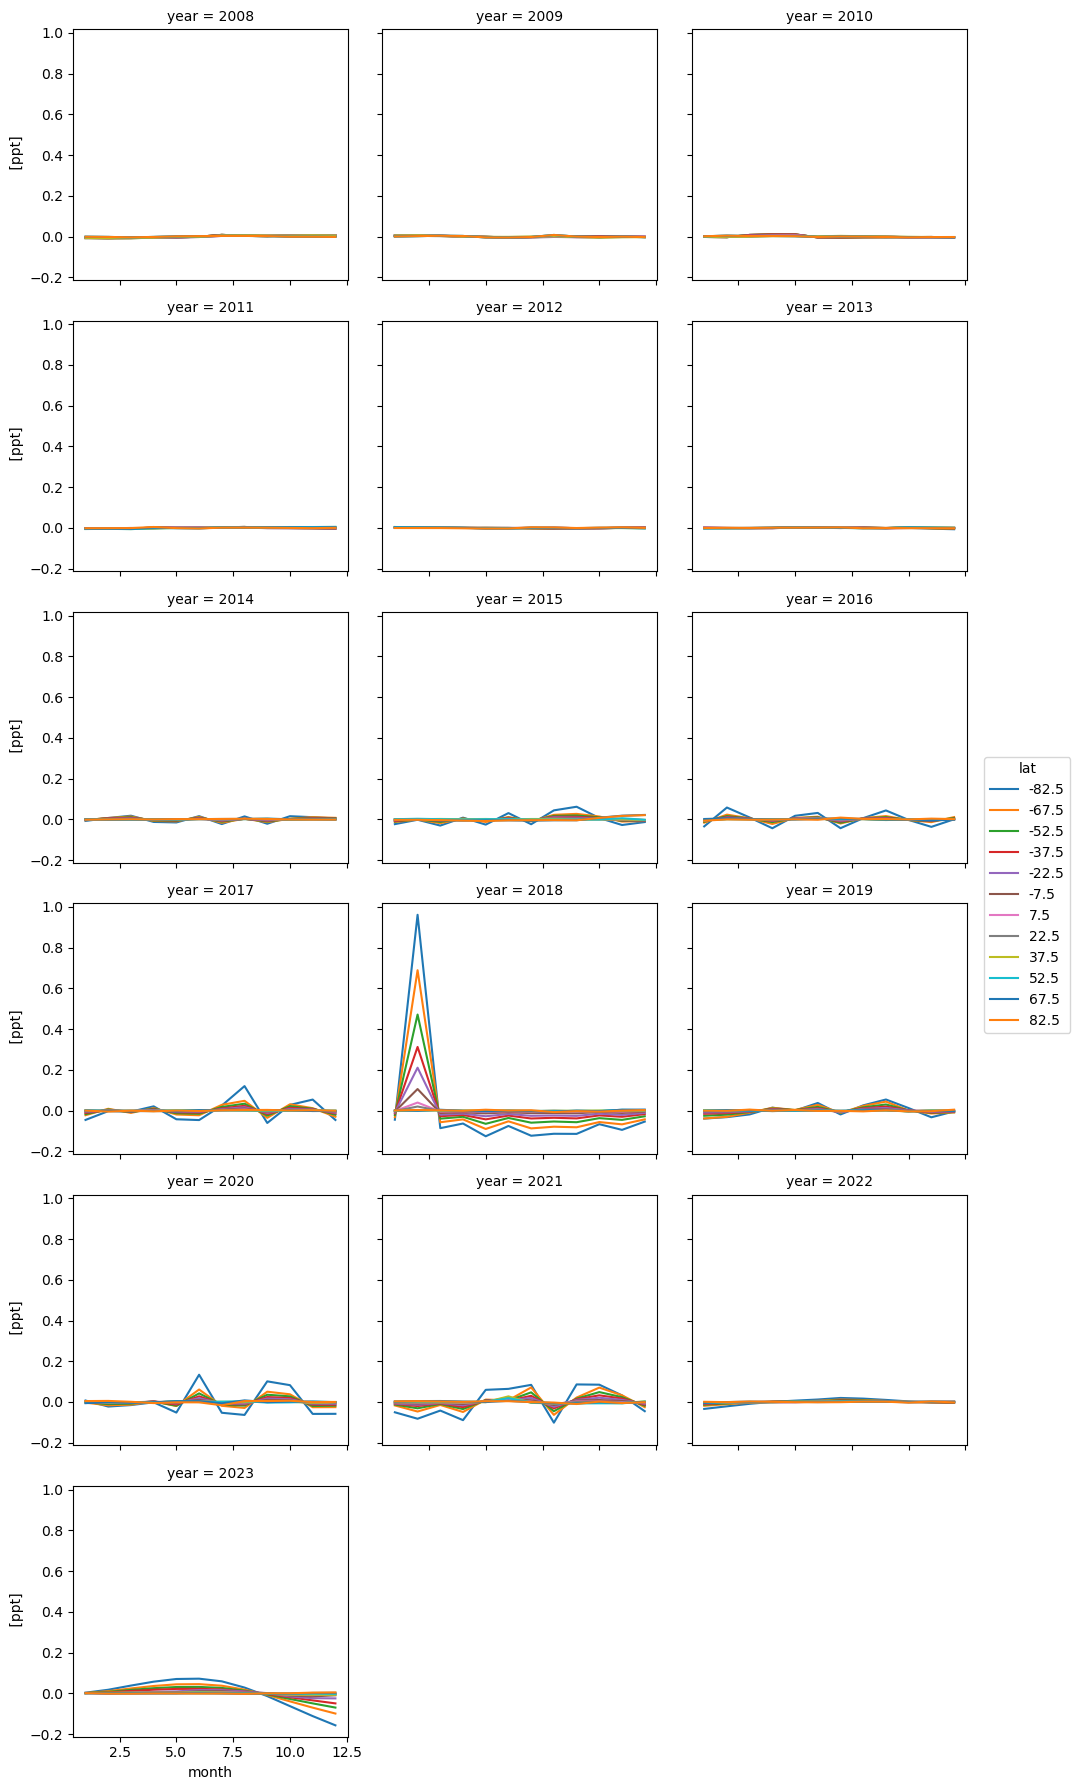

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

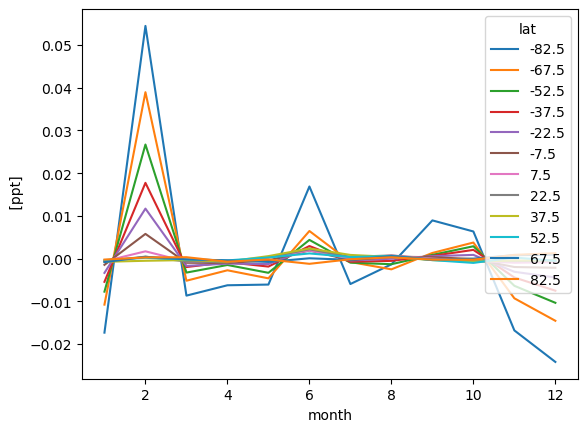

In [22]:
seasonality.plot.line(hue="lat")

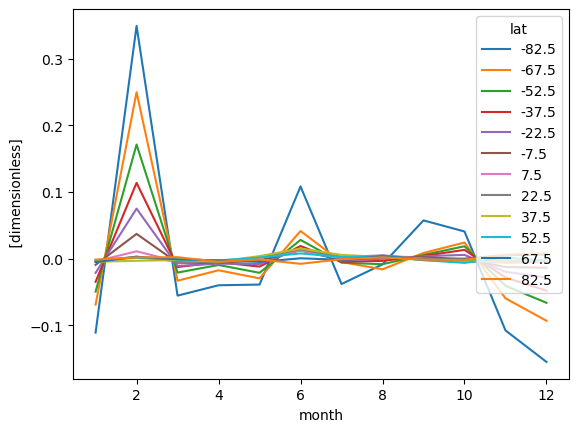

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[0.07385919201836115 0.08262810615453789 0.08995564276382288 0.09549427247293146 0.11128996335289378 0.12156060211923612 0.134128271711626 0.14356841870103845 0.1548575933343679 0.17051855183989437 0.19522189696623793 0.19833255839806244 0.20950134226273986 0.2305834786568753 0.23435813881875064 0.2502047994277426]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.8274449536904627] [0.40700908004382014] [0.22540073312282696] [0.10873426558296952] [0.02205119281571207] [-0.06295359290214139] [-0.10841767639000502] [-0.11454925146292776] [-0.11694901604634908] [-0.11854639431059844] [-0.14022252884377528] [-0.10164553747160437]]
Units,ppt
Magnitude,[[-0.01615725955067327] [-0.012043579024329816] [-0.010887870815743472] [-0.024066517718501334] [-0.016786128223792933] [-0.014116216947449804] [0.0028587274984673877] [0.008551694609791147] [0.02279544497307505] [0.03298550961081367] [0.09533013891304147] [0.015483158342861422] [0.02312791847730986] [0.06218746547192733] [-0.022545974209711106] [-0.023624561386140296]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.11108276309446799 0.34901083776749364 -0.05554484115818436 -0.040014830566309355 -0.03896975641189861 0.10815493013842886 -0.038152230763832354 -0.008622924392532873 0.057286203114090814 0.04067826726970929 -0.10774672054152025 -0.15499813495284867] [-0.06906578807554598 0.24960565831909975 -0.03319559162369882 -0.017541990057145358 -0.0296205563780158 0.04137273348801701 -0.005149707589898298 -0.016105247633032692 0.008472969919809545 0.024083884722306333 -0.059577161925389 -0.09328047484433083] [-0.0495866778636868 0.17108484065967844 -0.02099309241574017 -0.009590302632785147 -0.021317775466763486 0.02802807361278472 -0.006101556850183918 -0.008437290382484903 0.0055358672875444985 0.018497747551551615 -0.04080412044421804 -0.06631663480905987] [-0.03484293753930448 0.11360279951778761 -0.012677159678233256 -0.005423731425853031 -0.011978149408589876 0.018829251715794245 -0.004727027225400767 -0.0034137701117468774 0.004038164583832752 0.013065041836020872 -0.02832692738693738 -0.04814623148283831] [-0.021459823728445893 0.07494953168292075 -0.010940748167244472 -0.007564622698402066 -0.008224955842287794 0.015269293140957568 -0.0028184889229027747 -0.00024186796083107255 0.0035876127128418515 0.005551776967375137 -0.019786749046375427 -0.028321372476707872] [-0.009401782243074574 0.03704802799113135 -0.006263270965877599 -0.006440956018987383 -0.0027104952494399212 0.012264719004023742 -0.002404531701746125 0.0029254501815432323 0.0020684879661286063 -0.00067564121954463 -0.012633646752403489 -0.013776607788448287] [-0.004005564515394267 0.010909401008884167 -0.004469146840218687 -0.005356679679510453 0.0014424788972902856 0.012099365166443278 -0.00019453791809832954 0.0046536674254298496 1.4645096839357955e-05 -0.003359668671366556 -0.006267855885465412 -0.005466255782535899] [-0.003847515099866673 0.0029066511090694793 -0.004392410141551181 -0.005601207472658423 0.0019154896053749496 0.013928645105712577 0.0025527831764567167 0.004712121857715406 -0.0009950259657172719 -0.003966945475876457 -0.003749251029005288 -0.0034634611360149295] [-0.004838377818783141 -0.0032675702288374664 -0.0022406383049424655 -0.0044578728024645365 0.003697109265658981 0.015088917755861941 0.005493759469819378 0.0025064309969191475 -0.002253939126273342 -0.004467921777960522 -0.0029302108195348826 -0.0023298205304211807] [-0.0022315695060757612 0.0011608244027083532 -0.0012906788210186792 -0.0027336708841138647 0.0015840501697121211 0.00775562015303574 0.002370323648411133 0.0038057087561727647 -0.002287376468592126 -0.0064409184025781075 0.0016133098416080277 -0.0033056901913991405] [-0.0052546993349704045 0.002629003566139508 -0.0010721178858676403 -0.0026684166557517804 -0.005005104100283465 0.0004657714386064383 -0.0018859790543043977 0.0036902999981529424 -0.0018710948702731604 -6.6877264240095e-05 0.00508674967678919 0.005952459879168146] [-0.0014784751882270005 0.0017353835788197047 0.0020845534695239113 -0.0046659534777662715 -0.0013619392639830999 -0.007829612638385894 -0.0009912594661032482 0.0019695034560683502 -0.0015926045478040702 -0.0016136546353866358 0.005616623967726605 0.008127458348363955]]
Units,dimensionless
